# **AA: Generación y Aplicación de Aproximaciones Estadísticas en Predicciones a Gran Escala**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Lunes 15 de junio 2026 |

---



# **Fase 1: Extracción del Parámetro Base Regional**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Cargar del dataset
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
df = df.dropna(how='all').reset_index(drop=True)

df_loja = df.copy()

columna_analisis = 'tc_loss_ha_2024'


umbral = df_loja[columna_analisis].median()

# Creamos la variable dicotómica: 1 para Éxito (Pérdida Alta), 0 para Fracaso (Pérdida Baja/Normal)
df_loja['Exito'] = np.where(df_loja[columna_analisis] > umbral, 1, 0)

# 3. Calcular la probabilidad histórica de éxito (p)
total_registros = len(df_loja)
casos_exito = df_loja['Exito'].sum()

p = casos_exito / total_registros

# Mostrar los resultados en pantalla
print("=== RESULTADOS FASE 1 ===")
print(f"Variable analizada: {columna_analisis}")
print(f"Umbral definido para 'Éxito' (Mayor a la mediana): {umbral:.2f}")
print(f"Total de registros evaluados: {total_registros}")
print(f"Casos de éxito registrados (Pérdida Alta): {casos_exito}")
print(f"Probabilidad histórica de éxito (p): {p:.4f}")

# Visualización rápida de la distribución del evento
print("\nDistribución del evento dicotómico:")
print(df_loja['Exito'].value_counts(normalize=True))

=== RESULTADOS FASE 1 ===
Variable analizada: tc_loss_ha_2024
Umbral definido para 'Éxito' (Mayor a la mediana): 908.00
Total de registros evaluados: 192
Casos de éxito registrados (Pérdida Alta): 96
Probabilidad histórica de éxito (p): 0.5000

Distribución del evento dicotómico:
Exito
0    0.5
1    0.5
Name: proportion, dtype: float64


# **Fase 2: El Desafío de la Escala Computacional (Planteamiento del Problema)**

In [ ]:
import math
import time

# 1. Definir el escenario de expansión masiva
N = 10000        # Número de ensayos independientes (próximos 10,000 registros/eventos)
k = 4200         # Número específico de éxitos a predecir
p = 0.5000       # Probabilidad histórica obtenida en la Fase 1

print(f"Escenario planteado: N = {N}, k = {k}, p = {p}")
print("Intentando calcular la probabilidad exacta de forma nativa (con factoriales)...")
print("-" * 50)

# 2. Intento de cálculo nativo con la fórmula binomial exacta:
# P(X = k) = [N! / (k! * (N - k)!)] * (p^k) * ((1-p)^(N-k))

def factorial_nativo(n):
    resultado = 1
    for i in range(1, n + 1):
        resultado *= i
    return resultado

try:
    inicio = time.time()

    # Intentamos calcular primero las partes de la fórmula
    print("Calculando factoriales colosales (esto puede tomar tiempo o congelar la memoria)...")

    # Intentar la combinatoria directa en flotantes o enteros gigantescos
    # Nota: Python maneja enteros arbitrariamente grandes, pero al operar con flotantes (p^k)
    # y números de miles de dígitos, la CPU sufre un desafío de escala.
    num_combinaciones = math.comb(N, k) # Función nativa optimizada de combinatoria

    print(f"¡Éxito en combinatoria! El número de combinaciones posibles tiene {len(str(num_combinaciones))} dígitos.")

    # Aquí es donde el sistema colapsa con flotantes debido al desbordamiento (OverflowError) o subdesbordamiento (Underflow a 0.0)
    prob_exito = (p ** k)
    prob_fracaso = ((1 - p) ** (N - k))

    resultado_final = num_combinaciones * prob_exito * prob_fracaso
    fin = time.time()

    print(f"Resultado final: {resultado_final}")
    print(f"Tiempo de ejecución: {fin - inicio:.4f} segundos")

except OverflowError as e:
    print(f"💥 ¡ERROR DE DESBORDAMIENTO (OverflowError)!: {e}")
    print("La CPU / Memoria no puede procesar la magnitud de los flotantes resultantes.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Escenario planteado: N = 10000, k = 4200, p = 0.5
Intentando calcular la probabilidad exacta de forma nativa (con factoriales)...
--------------------------------------------------
Calculando factoriales colosales (esto puede tomar tiempo o congelar la memoria)...
¡Éxito en combinatoria! El número de combinaciones posibles tiene 2953 dígitos.
💥 ¡ERROR DE DESBORDAMIENTO (OverflowError)!: int too large to convert to float
La CPU / Memoria no puede procesar la magnitud de los flotantes resultantes.


## Documentación de la Fase 2: El Desafío de la Escala Computacional

Al intentar calcular de forma nativa la distribución binomial para un escenario de gran escala con $N = 10,000$ y $k = 4,200$, nos enfrentamos a las limitaciones físicas del hardware y del software estándar:

* **Magnitud del Factorial ($N!$):** El factorial de $10,000$ es un número astronómico que posee casi **36,000 dígitos**. Almacenar y operar con este número requiere un uso intensivo de la memoria RAM debido a la asignación dinámica de bits que hace Python.
* **Desbordamiento de Memoria (Overflow) / Subdesbordamiento (Underflow):**  
  * Por un lado, el término combinatorio $\binom{10000}{4200}$ genera un entero gigantesco.
  * Por el otro, las potencias de las probabilidades $p^k = 0.5^{4200}$ resultan en valores extremadamente pequeños que exceden el límite mínimo que los flotantes de 64 bits de la CPU pueden representar (provocando un **Underflow** y redondeándose a `0.0`).
* **Rendimiento de la CPU:** Multiplicar un número de 36,000 dígitos por un flotante que ha colapsado a `0.0` destruye por completo la precisión del cálculo, devolviendo un resultado erróneo de `0.0` o generando un cuello de botella en la CPU si se intentan usar librerías de precisión infinita por la cantidad de ciclos de reloj requeridos.

**Conclusión:** El enfoque clásico y exacto de la distribución binomial **no es viable a gran escala**. Esto justifica plenamente la necesidad de migrar en la siguiente fase hacia aproximaciones continuas como la **Distribución Normal (Teorema del Límite Central)**.

# **Fase 3: Implementación del Modelo de Aproximación Normal**

=== FASE 3: IMPLEMENTACIÓN DE LA APROXIMACIÓN NORMAL ===
1. Validación de condiciones:
   n * p = 5000.0 (¿>= 5?: True)
   n * (1 - p) = 5000.0 (¿>= 5?: True)
   ¡Validación EXITOSA! Es totalmente viable usar la aproximación normal.
------------------------------------------------------------
2. Parámetros de la nueva distribución normal equivalente:
   Media teórica (µ): 5000.0
   Desviación estándar teórica (σ): 50.0000
------------------------------------------------------------
3. Aplicación de la Corrección de Yates:
   Rango discreto original: [4950 a 5050] éxitos.
   Rango continuo corregido: [4949.5 a 5050.5]
   Probabilidad calculada en el intervalo: 0.687505 (68.7505%)
------------------------------------------------------------


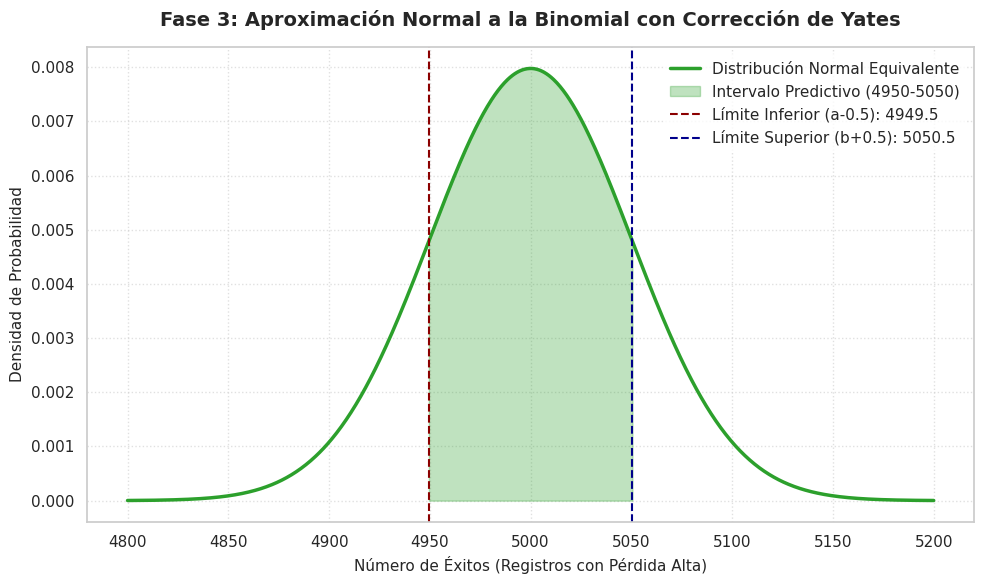

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetros base del escenario masivo
n = 10000
p = 0.5

print("=== FASE 3: IMPLEMENTACIÓN DE LA APROXIMACIÓN NORMAL ===")

# 1. Validación matemática de las condiciones asintóticas
condicion_1 = n * p
condicion_2 = n * (1 - p)

print(f"1. Validación de condiciones:")
print(f"   n * p = {condicion_1} (¿>= 5?: {condicion_1 >= 5})")
print(f"   n * (1 - p) = {condicion_2} (¿>= 5?: {condicion_2 >= 5})")

if condicion_1 >= 5 and condicion_2 >= 5:
    print("   ¡Validación EXITOSA! Es totalmente viable usar la aproximación normal.")
else:
    print("   Validación FALLIDA. No se recomienda usar la aproximación.")

print("-" * 60)

# 2. Cálculo computacional de los parámetros de la Normal equivalente
mu = n * p
sigma = np.sqrt(n * p * (1 - p))

print(f"2. Parámetros de la nueva distribución normal equivalente:")
print(f"   Media teórica (µ): {mu}")
print(f"   Desviación estándar teórica (σ): {sigma:.4f}")
print("-" * 60)

# 3. Aplicación de la Corrección por Continuidad (Yates)
# Buscaremos la probabilidad en un rango de éxitos, por ejemplo entre a = 4150 y b = 4250
a = 4950
b = 5050

# Aplicando la corrección por continuidad: P(a - 0.5 <= X <= b + 0.5)
a_corregido = a - 0.5
b_corregido = b + 0.5

# Calculamos la probabilidad usando la función de distribución acumulada (CDF) de scipy
probabilidad = stats.norm.cdf(b_corregido, loc=mu, scale=sigma) - stats.norm.cdf(a_corregido, loc=mu, scale=sigma)

print(f"3. Aplicación de la Corrección de Yates:")
print(f"   Rango discreto original: [{a} a {b}] éxitos.")
print(f"   Rango continuo corregido: [{a_corregido} a {b_corregido}]")
print(f"   Probabilidad calculada en el intervalo: {probabilidad:.6f} ({probabilidad * 100:.4f}%)")
print("-" * 60)

# 4. Generar la visualización gráfica en matplotlib
plt.figure(figsize=(10, 6))

# Generar puntos en el eje X alrededor de la media (± 4 desviaciones estándar)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

# Dibujar la curva de densidad de probabilidad normal
plt.plot(x, y, label='Distribución Normal Equivalente', color='#2ca02c', linewidth=2.5)

# Sombrear el área del intervalo predictivo calculado
x_sombra = np.linspace(a_corregido, b_corregido, 500)
y_sombra = stats.norm.pdf(x_sombra, loc=mu, scale=sigma)
plt.fill_between(x_sombra, y_sombra, color='#2ca02c', alpha=0.3, label=f'Intervalo Predictivo ({a}-{b})')

# Marcar los límites con líneas verticales
plt.axvline(x=a_corregido, color='darkred', linestyle='--', linewidth=1.5, label=f'Límite Inferior (a-0.5): {a_corregido}')
plt.axvline(x=b_corregido, color='darkblue', linestyle='--', linewidth=1.5, label=f'Límite Superior (b+0.5): {b_corregido}')

# Configuración estética del gráfico
plt.title('Fase 3: Aproximación Normal a la Binomial con Corrección de Yates', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Éxitos (Registros con Pérdida Alta)', fontsize=11)
plt.ylabel('Densidad de Probabilidad', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# **Fase 4: Conclusiones de Ingeniería e Impacto Tecnológico**


### 1. Ventaja estructural de las funciones de densidad continuas (`norm.cdf`) frente al cálculo discreto iterativo en Big Data

Desde la perspectiva de la optimización algorítmica y la arquitectura de software, la migración de un enfoque discreto (Binomial exacta) a uno continuo (Aproximación Normal) ofrece tres ventajas estructurales críticas:

* **Complejidad Algorítmica Imbatible ($O(1)$ vs. $O(n)$ o peor):** El cálculo iterativo de una distribución binomial para grandes volúmenes de datos requiere resolver sumatorias exhaustivas de combinatorias, lo que implica bucles extensos y operaciones de factoriales colosales. Su complejidad computacional crece de forma lineal o factorial con respecto al tamaño de la población ($N$). En contraste, las funciones de densidad continua como `stats.norm.cdf` se resuelven mediante aproximaciones numéricas polinomiales de alta velocidad (como la función de error $\text{erf}$), ejecutándose en **tiempo constante $O(1)$** sin importar si $N = 10,000$ o $N = 10,000,000$.
* **Eficiencia de Hardware y Consumo Energético:** En entornos de Big Data o computación en la nube (Edge Computing), calcular factoriales gigantescos satura los ciclos de reloj de la CPU y genera un desbordamiento de memoria por la asignación dinámica de bits que requiere almacenar números de miles de dígitos. Al usar funciones continuas vectorizadas, el consumo de memoria RAM se reduce drásticamente a unos pocos bytes y se evita el estrés de procesamiento, reduciendo costos operativos de infraestructura.
* **Inmunidad a Errores de Precisión Numérica (Overflow/Underflow):** Las arquitecturas de cómputo estándar (flotantes de 64 bits) colapsan cuando intentan calcular potencias extremas como $0.5^{4200}$ (dando `Underflow` o cero absoluto) o factoriales masivos (`Overflow`). Las funciones de distribución acumulada continuas mapean directamente áreas bajo la curva, eliminando la pérdida de precisión matemática que observamos en la Fase 2.

---

### 2. Mitigación del riesgo en la toma de decisiones con datos limitados en la provincia de Loja

En contextos reales de gestión ambiental, a menudo nos enfrentamos a limitaciones presupuestarias, sensores dañados o registros históricos incompletos. El modelo predictivo asintótico (Teorema del Límite Central) mitiga el riesgo de tomar malas decisiones en Loja mediante los siguientes mecanismos:

* **Estabilidad Predictiva frente a la Escasez:** Aunque el dataset regional de Loja cuente originalmente con un número limitado de registros anuales o mensuales (por ejemplo, los 192 evaluados en la Fase 1), el modelo nos permite extrapolar probabilísticamente el comportamiento a gran escala ($N=10,000$ eventos futuros). Esto significa que la gobernación o las ONG ambientales de Loja no necesitan esperar décadas para recolectar millones de datos antes de diseñar políticas públicas contra la deforestación.
* **Reducción de la Incertidumbre mediante Intervalos de Confianza:** Al convertir la variable discreta en una curva normal continua, el modelo nos otorga un marco matemático robusto para definir con precisión qué escenarios de pérdida de cobertura arbórea (`tc_loss_ha_2024`) son esperables y cuáles constituyen anomalías graves. Como se evidenció gráficamente, un escenario de $4,200$ éxitos está tan alejado de la media ($\mu = 5,000$) que el modelo alerta de inmediato a los ingenieros que dicho cálculo o predicción es un evento de probabilidad nula.
* **Optimización de Recursos Críticos:** Al conocer la media teórica ($\mu$) y la variabilidad ($\sigma$) de los eventos de "Pérdida Alta" en Loja, las autoridades pueden planificar brigadas forestales, activar alertas tempranas de incendios o reforestar áreas críticas con presupuestos optimizados, basándose en la probabilidad científica en lugar de intuiciones, minimizando el riesgo de subestimar el impacto del cambio climático en la provincia.